# Lab 6.0x - Advertising budget and sales analysis

Source: <https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/>

This dataset contains data about the sales of a product in relation to the advertising budgets spent on TV, radio and newspaper. All values are in thousands of dollars, except for sales which is in thousands of units. The dataset contains 200 rows and 4 variables: TV, Radio, Newspaper, and Sales.

In [1]:
# Import the necessary libraries
# Importing the necessary packages
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

In [2]:
advertising = pd.read_csv('https://media.geeksforgeeks.org/wp-content/uploads/20240522145649/advertising.csv')
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


1. Visualize the dataset. Specifically, show the relationship between the three advertising budgets (independent variables) and sales (dependent variable). Which of the three advertising budgets seems to have the strongest relationship with sales?

    (*tip*: the Seaborn `pairplot()` function can be useful here, so you don't have to create three separate scatter plots).

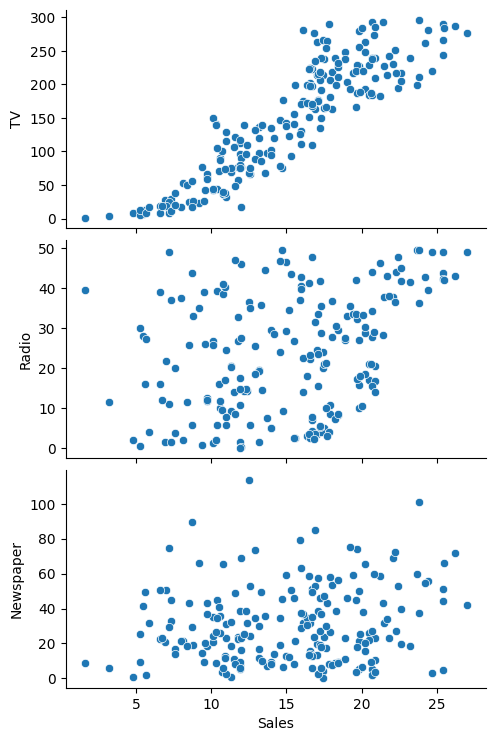

In [ ]:
independent = 'Sales'
grid = sns.pairplot(data=advertising, x_vars=independent, y_vars=['TV','Radio','Newspaper'], aspect=2)

print(f'TV advertising seems to have the greatest corelation with sales.')


2. Calculate the correlation coefficients and the coefficient of determination (R²) for the relationship between each advertising budget and sales.

    Which advertising budget has the highest R² value, and what does this imply about its relationship with sales? Is it actually worth investing in all three advertising channels?

In [ ]:
r_tv = np.corrcoef(advertising['TV'], advertising[independent])[0][1]
r_radio = np.corrcoef(advertising['Radio'], advertising[independent])[0][1]
r_newspaper = np.corrcoef(advertising['Newspaper'], advertising[independent])[0][1]

r2_tv = r_tv**2
r2_radio = r_radio**2
r2_newspaper = r_newspaper**2

print(f'TV => R = {r_tv}, R2 = {r2_tv}')
print(f'Radio => R = {r_radio}, R2 = {r2_radio}')
print(f'Newspaper => R = {r_newspaper}, R2 = {r2_newspaper}')

TV => R = 0.9012079133023305, R2 = 0.8121757029987409
Radio => R = 0.34963109700766937, R2 = 0.12224190399478631
Newspaper => R = 0.1579600261549263, R2 = 0.024951369862865


These values imply that it is definitely worth investing in TV. Investing in Newspaper advertising only 2% of the variance in Sales can be explained by the corelation with the newspaper advertising budget. This means it has barely any effect on sales and might thus not be worth investing in. Similarly only 12% of the variance in Sales can be explained by the corelation with the radio advertising budget. Although it does have a weak relationship, the relationship might not be enough to decide it's worth investing into.

TV advertisements must definitely be invested in, they have a strong effect on the amount of sales.

Note: All three channels have a positive relationship, so none of them are completely useless.

3. If you take only the best performing advertising channel into account, how would you predict sales based on the advertising budget for that channel?

    What would be the predicted sales if you spend $100,000 on that channel?

In [ ]:
scope, intercept = np.polyfit(advertising['TV'], advertising['Sales'], deg=1)

print(f'Scope: {scope}, intercept: {intercept}')
predicted_sales = intercept + scope * 100
print(f'A budget of 100.000 in TV advertising, should result in {np.round(predicted_sales*1000, 0)}k units sold.')

Scope: 0.05546477046955883, intercept: 6.974821488229894
A budget of 100k in TV advertising, should result in 12521.0k units sold.


4. In the previous questions we used simple linear regression. We could also use multiple linear regression to predict Sales using TV, Radio, and Newspaper. Multiple regression looks at the relationship between several variables and the target simultaneously. Each coefficient expresses the effect of that variable while holding the others constant

    Use AI to implemnt multiple linear regression on the given dataset.

## Answers

- The correlations between the advertising budgets and sales are as follows:
    - TV: 0.9012
    - Radio: 0.3496
    - Newspaper: 0.1580
- The R² values for the relationship between each advertising budget and sales are:
    - TV: 0.8122
    - Radio: 0.1222
    - Newspaper: 0.0250
- Regression line for TV advertising: Sales = 6.9748 + 0.0555 * TV
- Predicted sales for $100,000 spent on TV advertising: 12521 units